In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv')

print("Rows and Columns:", df.shape)

Rows and Columns: (42448764, 9)


In [2]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [3]:
# Show first 5 rows with actual data
print(df.head())

                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708-9857-6336556b0fc

In [5]:
# Count each event type
print(df['event_type'].value_counts())

event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64


In [6]:
# Calculate conversion rate
total_views = df[df['event_type'] == 'view']['user_id'].count()
total_carts = df[df['event_type']== 'cart']['user_id'].count()
total_purchases = df[df['event_type']== 'purchase']['user_id'].count()

print("Total Views:", total_views)
print("Total Carts:", total_carts)
print("Total Purchases:", total_purchases)
print("----------------------------------")
print("View to Cart Rate:", round(total_carts/total_views*100, 2), "%")
print("Cart to Purchase Rate:", round(total_purchases/total_carts*100, 2), "%")
print("Overall Conversion Rate:", round(total_purchases/total_views*100, 2), "%")

Total Views: 40779399
Total Carts: 926516
Total Purchases: 742849
----------------------------------
View to Cart Rate: 2.27 %
Cart to Purchase Rate: 80.18 %
Overall Conversion Rate: 1.82 %


In [8]:
# Top 10 brands by revenue
top_brands = df[df['event_type'] == 'purchase'].groupby('brand')['price'].agg(
    total_revenue='sum',
    total_purchases='count',
    avg_price='mean',
).round(2).sort_values('total_revenue', ascending=False).head(10)
print(top_brands)

         total_revenue  total_purchases  avg_price
brand                                             
apple     1.112093e+08           142873     778.38
samsung   4.640753e+07           172896     268.41
xiaomi    9.194033e+06            56616     162.39
huawei    4.883422e+06            23501     207.80
acer      3.576720e+06             6882     519.72
lg        3.387888e+06             8727     388.21
lucente   3.124113e+06            11578     269.83
sony      2.478197e+06             6729     368.29
oppo      2.412960e+06            10891     221.56
lenovo    1.752639e+06             4578     382.84


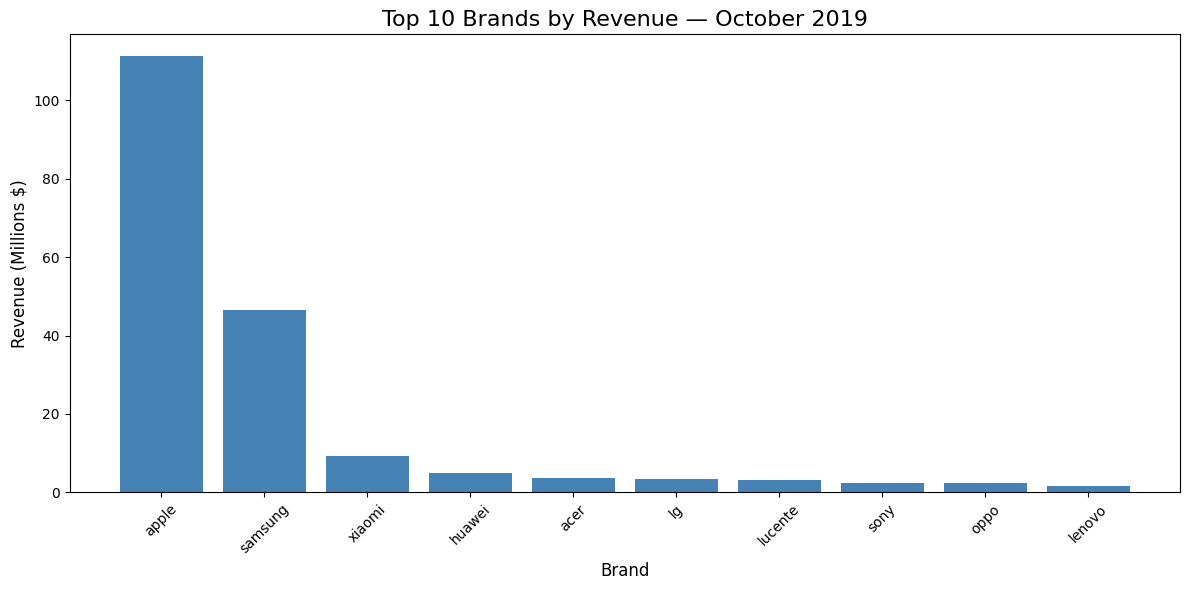

In [10]:
import matplotlib.pyplot as plt

# Create readable revenue numbers in millions
top_brands['revenue_millions'] = (top_brands['total_revenue'] / 1000000).round(2)

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_brands.index, top_brands['revenue_millions'], color='steelblue')
plt.title('Top 10 Brands by Revenue — October 2019', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Revenue (Millions $)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()